In [ ]:
import os
import json
import csv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as torch_data
import torchaudio
import tqdm.notebook as tqdm
from torch.utils.tensorboard import SummaryWriter
import dataset
import requests
import re

import IPython.display as ipd

%matplotlib inline

In [ ]:
def get_url(link):
    response = requests.get(link)
    page_content = response.text

    re_pattern = r'dispatcher.*?weblink_get.*?url":"(.*?)"'
    match = re.search(re_pattern , page_content)

    if match:
        url = match.group(1)
        parts = link.split('/')[-2:]
        url = f'{url}/{parts[0]}/{parts[1]}'
        return url
    
    return None

In [22]:
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("Using device:", DEVICE)

DATADIR = 'data'
FEATS = 80
SAMPLE_RATE = 16000
LOADER_WORKERS = 0 

Using device: mps


In [3]:
%load_ext autoreload
%autoreload 2

## 0. Preprocessing

In [ ]:
mel = torchaudio.transforms.MelSpectrogram(sample_rate=SAMPLE_RATE, n_mels=FEATS)
resample = torchaudio.transforms.Resample(orig_freq=48000, new_freq=SAMPLE_RATE)
transform = torch.nn.Sequential(resample, mel, torchaudio.transforms.AmplitudeToDB())

with open(os.path.join(DATADIR, 'train_data/train_opus/word_bounds.json'), 'r') as f:
    word_bounds = json.load(f)
positive_ids = set(word_bounds.keys())

full_trainset = dataset.Dataset(os.path.join(DATADIR, 'train_data/train_opus/audio'), transform, positive_ids)

trainset, valset = torch_data.random_split(full_trainset, [0.85, 0.15], generator=torch.Generator().manual_seed(42))

testset = dataset.Dataset(os.path.join(DATADIR, 'test_data/test_opus/audio'), transform)

print(f"Train size: {len(trainset)}, Val size: {len(valset)}, Test size: {len(testset)}")

Train size: 76500, Val size: 13500, Test size: 27000


torch.Size([80, 321]) 0 data/train_data/train_opus/audio/4429310600649658263246361851188065803905.opus


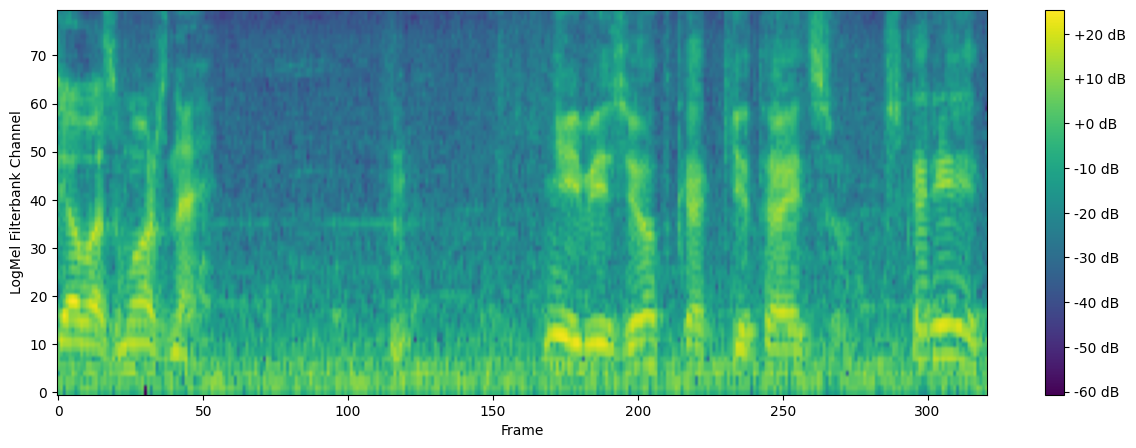

In [5]:
feats, label, path = trainset[0]
waveform, sr = torchaudio.load(path)
ipd.display(ipd.Audio(waveform.numpy(), rate=sr))
print(feats.shape, label, path)

def plot_feats(feats: torch.Tensor):
    plt.figure(figsize=(15, 5))
    plt.imshow(feats.numpy(), origin='lower', aspect='auto')
    plt.xlabel('Frame')
    plt.ylabel('LogMel Filterbank Channel')
    plt.colorbar(format='%+2.0f dB')
    plt.show()

plot_feats(feats)

In [6]:
loader = torch_data.DataLoader(
    trainset,
    shuffle=True,
    batch_size=128,
    collate_fn=dataset.collate_fn,
    num_workers=LOADER_WORKERS,
)
loader_iter = iter(loader)
batch_feats, batch_labels, batch_paths = next(loader_iter)
print(batch_feats.shape, batch_labels.shape, batch_paths[:3])
print(batch_labels.count_nonzero().item(), len(batch_labels))

torch.Size([128, 80, 321]) torch.Size([128]) ['data/train_data/train_opus/audio/3452505518840440337040006761233539274848.opus', 'data/train_data/train_opus/audio/7489217475342785071764950575176386291036.opus', 'data/train_data/train_opus/audio/4649289256946786339810454389039227149981.opus']
73 128


In [ ]:
def task_metric(scores: list[int], labels: list[int], n_thr: int=100):
    scores = np.array(scores)
    labels = np.array(labels)

    thresholds = np.quantile(scores, np.linspace(0.0, 1.0, n_thr))

    best_score = -1
    best_thr = None

    for thr in thresholds:
        preds = scores >= thr

        TP = ((preds == 1) & (labels == 1)).sum()
        FN = ((preds == 0) & (labels == 1)).sum()
        FP = ((preds == 1) & (labels == 0)).sum()
        TN = ((preds == 0) & (labels == 0)).sum()

        FRR = FN / (TP + FN)
        FAR = FP / (FP + TN)

        score = 2 * (1 - FRR) * (1 - FAR) / ((1 - FRR) + (1 - FAR))

        if score > best_score:
            best_score = score
            best_thr = thr

    return best_score, best_thr

In [55]:
def train_stage(model, opt, batch_size: int = 256, writer: SummaryWriter = None, epoch: int = 0):
    loader = torch_data.DataLoader(
        trainset,
        shuffle=True,
        batch_size=batch_size,
        collate_fn=dataset.collate_fn,
        num_workers=LOADER_WORKERS,
    )
    loss_sum = 0.0
    batches = 0
    for i, (X, Y, _) in enumerate(tqdm.tqdm(loader)):
        logits = model.forward(X.to(DEVICE))
        loss = F.cross_entropy(logits, Y.to(DEVICE))
        loss_sum += loss.item()
        batches += 1
        opt.zero_grad()
        loss.backward()
        opt.step()
        
        # if writer is not None:
        #     global_step = epoch * len(loader) + i
        #     writer.add_scalar('Loss/train_batch', loss.item(), global_step)
            
    return loss_sum / batches

## 1. Baseline model

In [9]:
class Model(nn.Module):
    def __init__(self, input_shape: int, output_shape: int, hidden: int, kernel: int = 7, sride: int = 2):
        super().__init__()
        self._emb = nn.Sequential(
            nn.Conv1d(input_shape, hidden, kernel, stride=sride),
            nn.ReLU(),
            nn.Conv1d(hidden, hidden, kernel, stride=sride),
            nn.ReLU(),
            nn.Conv1d(hidden, hidden, kernel, stride=sride),
            nn.AdaptiveMaxPool1d(1),
        )
        self._final = nn.Linear(hidden, output_shape)

    def forward(self, X) -> tuple[torch.Tensor, torch.Tensor]:
        emb = self._emb(X).squeeze(2)
        return self._final(emb)

In [ ]:
def calc_eval_score(model: nn.Module, eval_set: torch_data.Dataset, batch_size: int=256):
    loader = torch_data.DataLoader(
        eval_set,
        batch_size=batch_size,
        collate_fn=dataset.collate_fn,
        num_workers=LOADER_WORKERS,
    )

    scores, labels = [], []
    model.eval()
    with torch.no_grad():
        for X, Y, _ in tqdm.tqdm(loader):
            logits = model(X.to(DEVICE))
            s = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            scores.extend(s)
            labels.extend(Y.numpy())

    best_score, best_thr = task_metric(scores, labels, n_thr=100)
    return best_score, best_thr

In [56]:
def train(
    model: nn.Module,
    opt,
    batch_size: int = 256,
    epochs: int = 1,
    eval_set: torch_data.Dataset = valset,
    train_fn = train_stage,
    writer: SummaryWriter = None
):
    train_losses = []
    eval_scores = []
    for epoch in range(epochs):
        model.train()
        train_loss = train_fn(model, opt, batch_size=batch_size, writer=writer, epoch=epoch)
        train_losses.append(train_loss)
        
        model.eval()
        eval_score, _ = calc_eval_score(model, eval_set, batch_size=batch_size)
        if eval_score > max(eval_scores, default=0):
            torch.save(model.state_dict(), f'best_model_{eval_score}.pth')
        eval_scores.append(eval_score)
        
        if writer is not None:
            writer.add_scalar('Loss/train_epoch', train_loss, epoch)
            writer.add_scalar('Score/eval', eval_score, epoch)
        
        ipd.clear_output()
        fig, axis = plt.subplots(1, 2, figsize=(15, 7))
        axis[0].plot(np.arange(1, epoch + 2), train_losses, label='train CE loss')
        axis[1].plot(np.arange(1, epoch + 2), eval_scores, label='eval')
        axis[0].set(xlabel='epoch', ylabel='CE Loss')
        axis[1].set(xlabel='epoch', ylabel='Harmonic mean(1-FAR, 1-FRR)')
        fig.legend()
        plt.show()
        print(f'Epoch {epoch + 1}. Train loss {train_losses[-1]}. Eval score {eval_scores[-1]}')

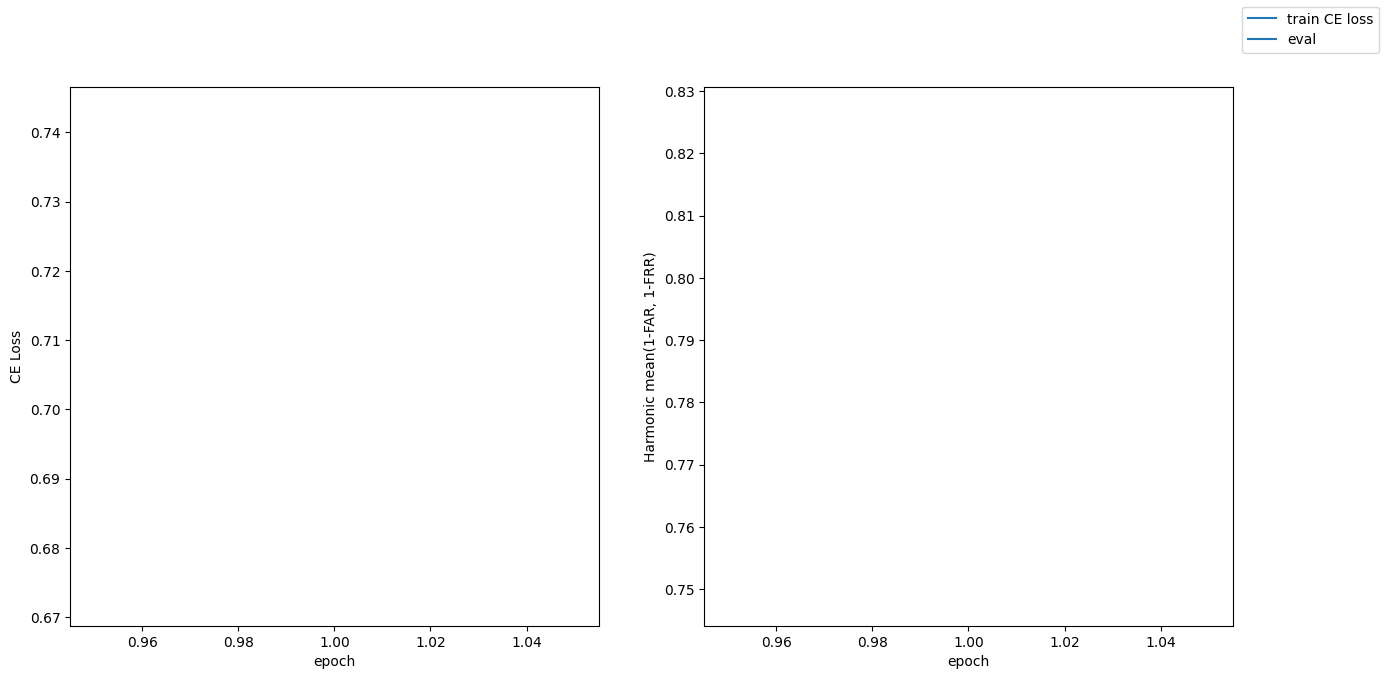

Epoch 1. Train loss 0.7076763628318556. Eval score 0.7874017310773002


In [27]:
model = Model(FEATS, 2, 128).to(DEVICE)
opt = optim.AdamW(model.parameters())
writer = SummaryWriter()
train(model, opt, writer=writer)

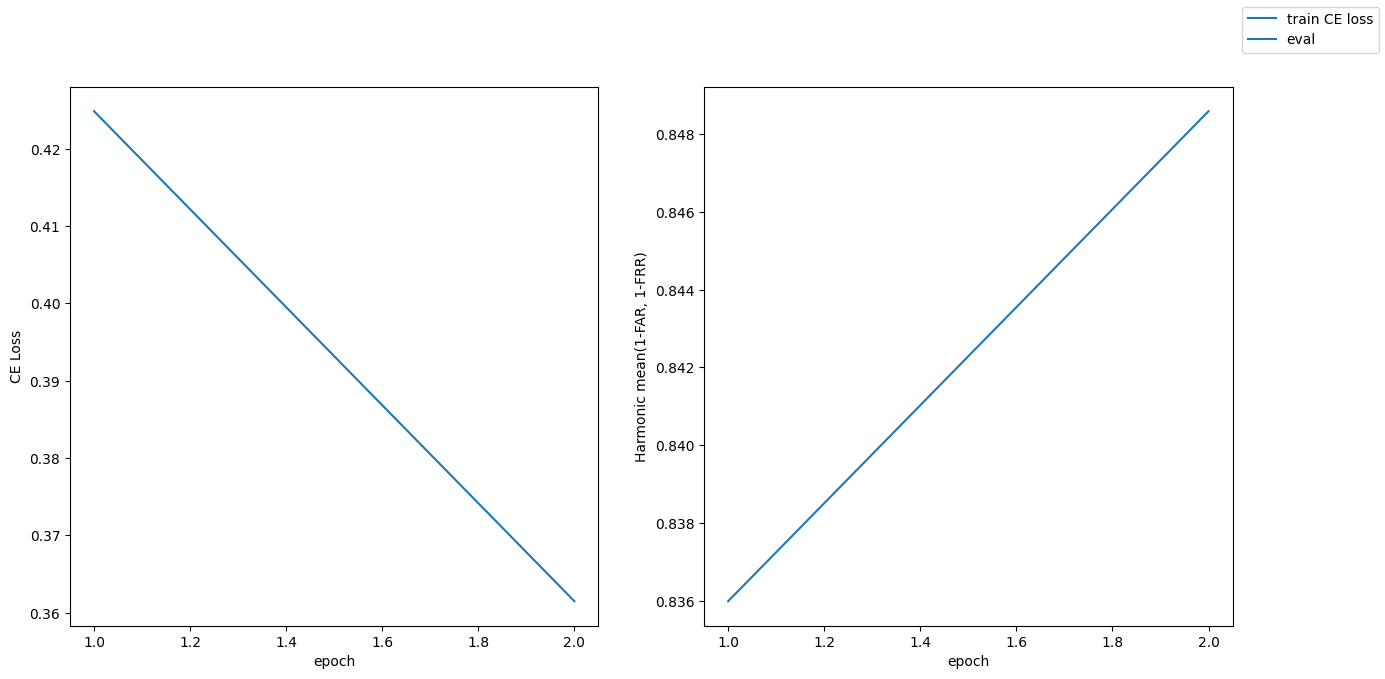

Epoch 2. Train loss 0.361503091245192. Eval score 0.8485896677195383


In [29]:
train(model, opt, writer=writer, epochs=2)

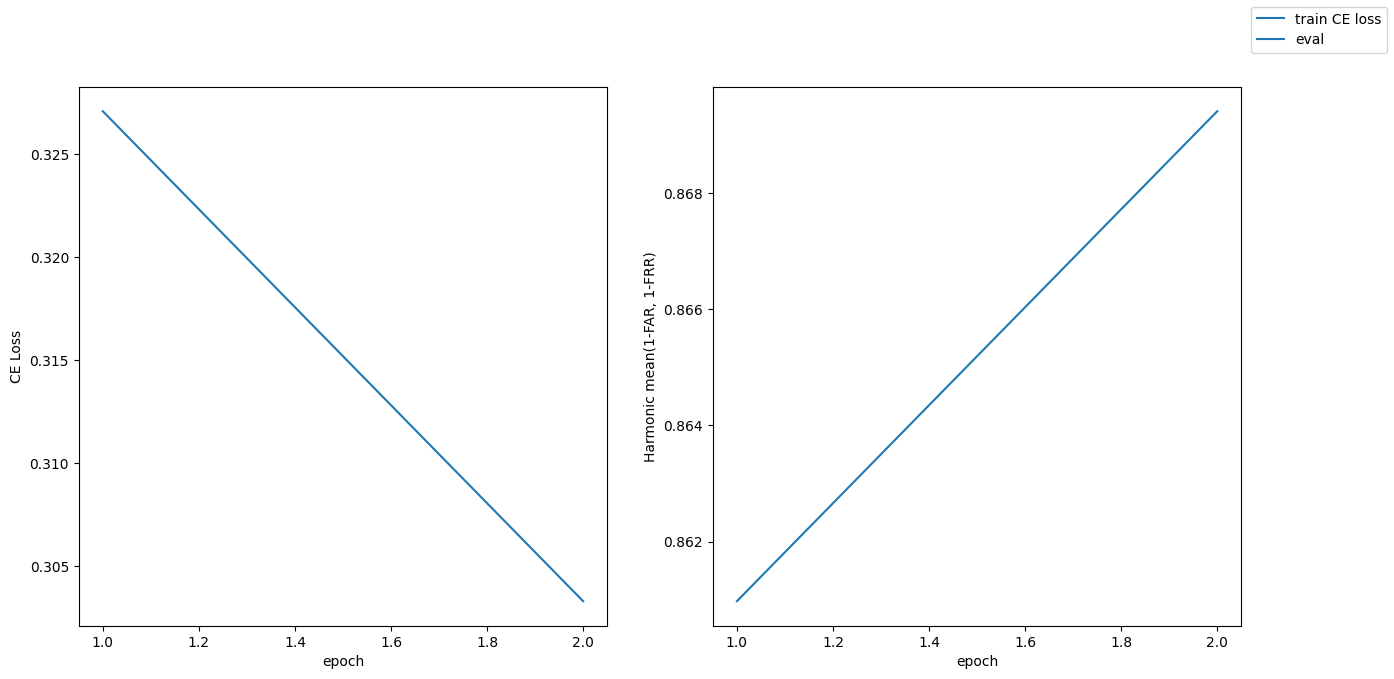

Epoch 2. Train loss 0.3032945788723968. Eval score 0.8694165614189919


In [31]:
train(model, opt, writer=writer, epochs=2)

In [32]:
model.eval()
print(calc_eval_score(model, torch_data.Subset(valset, range(1000)), batch_size=128))

  0%|          | 0/8 [00:00<?, ?it/s]

(np.float64(0.8713325323525906), np.float64(0.4194817144667084))


In [47]:
def save_test_preds(model: nn.Module, output_file: str = "submission.csv"):
    _, best_thr = calc_eval_score(model, valset, batch_size=256)
    print(f"{best_thr=}")
    rows = []
    testloader = torch_data.DataLoader(
        testset,
        shuffle=True,
        batch_size=256,
        collate_fn=dataset.collate_fn,
        num_workers=LOADER_WORKERS,
    )
    model.eval()
    with torch.no_grad():
        for X, _, paths in tqdm.tqdm(testloader):
            logits = model(X.to(DEVICE))
            scores = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = (scores >= best_thr).astype(int)
            ids = [dataset.audio_id_from_path(p) for p in paths]
            for id_, p in zip(ids, preds):
                rows.append((id_, int(p)))

    with open(output_file, "w") as f:
        writer = csv.writer(f)
        writer.writerow(["id", "label"])
        writer.writerows(rows)


In [ ]:
save_test_preds(model)

## 2. EcapaTDNN model

In [38]:
class SEBlock(nn.Module):
    def __init__(self, input_shape: int, reduction: int = 1):
        super().__init__()
        # <YOUR CODE IS HERE>
        self.mlp = nn.Sequential(
            nn.Linear(input_shape, input_shape // reduction),
            nn.ReLU(),
            nn.Linear(input_shape // reduction, input_shape),
            nn.Sigmoid()
        )

    def __call__(self, X):
        # <YOUR CODE IS HERE>
        channels = torch.mean(X, dim=-1) # [b, c]
        weights = self.mlp(channels) # [b, c]
        return X * weights.unsqueeze(-1) # [b, c, t]

In [39]:
class Res2Net(nn.Module):
    def __init__(self, hidden: int, dilation: int, scale: int, kernel_size: int = 3):
        super().__init__()
        assert hidden % scale == 0
        # <YOUR CODE IS HERE>
        self.scale = scale
        self.width = hidden // scale

        self.conv = nn.ModuleList([
            nn.Conv1d(self.width, self.width, kernel_size=kernel_size, padding='same', dilation=dilation)
            for _ in range(scale - 1)
        ])
        self.bn_relu = nn.Sequential(
            nn.BatchNorm1d(hidden),
            nn.ReLU()
        )

    def __call__(self, X):
        # <YOUR CODE IS HERE>
        splits = torch.split(X, self.width, dim=1)
        y = [splits[0]]
        for i in range(1, self.scale):
            if i == 1:
                sp = splits[i]
            else:
                sp = splits[i] + y[i - 1]
            sp = self.conv[i - 1](sp)
            y.append(sp) 
        out = torch.cat(y, dim=1)
        return self.bn_relu(out)

In [40]:
class EcapaBlock(nn.Module):
    def __init__(self, hidden: int, dilation: int, scale: int):
        super().__init__()
        # <YOUR CODE IS HERE>
        self.conv_in = nn.Sequential(nn.Conv1d(hidden, hidden, 1), nn.BatchNorm1d(hidden), nn.ReLU())
        self.res2net = Res2Net(hidden, dilation, scale)
        self.conv_out = nn.Sequential(nn.Conv1d(hidden, hidden, 1), nn.BatchNorm1d(hidden), nn.ReLU())
        self.se_block = SEBlock(hidden)

    def __call__(self, X):
        # <YOUR CODE IS HERE>
        out = self.conv_in(X)
        out = self.res2net(out)
        out = self.conv_out(out)
        out = self.se_block(out)
        return X + out

In [41]:
class AttentiveStatsPooling(nn.Module):
    def __init__(self, input_shape: int, hidden: int):
        super().__init__()
        # <YOUR CODE IS HERE>
        self.attn = nn.Sequential(
            nn.Conv1d(input_shape * 3, hidden, 1),
            nn.ReLU(),
            nn.Conv1d(hidden, input_shape, 1)
        )

    def forward(self, X):
        # X shape = [time, feats]
        # calc mean and std for X over time dimension
        # concatenate mean and std to X over feats dimension to make shape [time, feats * 3]
        # attention
        # weighted mean and std with weights from attention for original X
        
        # <YOUR CODE IS HERE> sps X shape = [feats, time]
        X_mean_expanded = X.mean(dim=-1)[..., None].expand_as(X)
        X_std_expanded = X.std(dim=-1)[..., None].expand_as(X)
        X_expanded = torch.cat([X, X_mean_expanded, X_std_expanded], dim=1)
        weight = F.softmax(self.attn(X_expanded), dim=-1)
        mean = torch.sum(weight * X, dim=-1)
        std = torch.sqrt(torch.sum(weight * (X**2), dim=-1) - mean ** 2 + 1e-5)
        return torch.cat([mean, std], dim=-1)

In [42]:
class EcapaTDNN(nn.Module):
    def __init__(self, input_shape: int, n_classes: int, output_shape: int):
        super().__init__()
        # <YOUR CODE IS HERE>
        self.conv_bn_relu = nn.Sequential(
            nn.Conv1d(input_shape, output_shape, kernel_size=5, padding='same', dilation=1),
            nn.BatchNorm1d(output_shape),
            nn.ReLU()
        )
        self.ecapa_block1 = EcapaBlock(output_shape, dilation=2, scale=8)
        self.ecapa_block2 = EcapaBlock(output_shape, dilation=3, scale=8)
        self.ecapa_block3 = EcapaBlock(output_shape, dilation=4, scale=8)
        self.conv_relu = nn.Sequential(
            nn.Conv1d(output_shape*3, 1536, kernel_size=1),
            nn.ReLU()
        )
        self.asp = AttentiveStatsPooling(1536, 512)
        self.fc = nn.Linear(3072, n_classes)

    def forward(self, X):
        # <YOUR CODE IS HERE>
        X = self.ecapa_block1(self.conv_bn_relu(X))
        out1 = self.ecapa_block2(X)
        out2 = self.ecapa_block3(out1)
        X = torch.cat([X, out1, out2], dim=1)
        X = self.conv_relu(X)
        X = self.asp(X)
        return self.fc(X) 

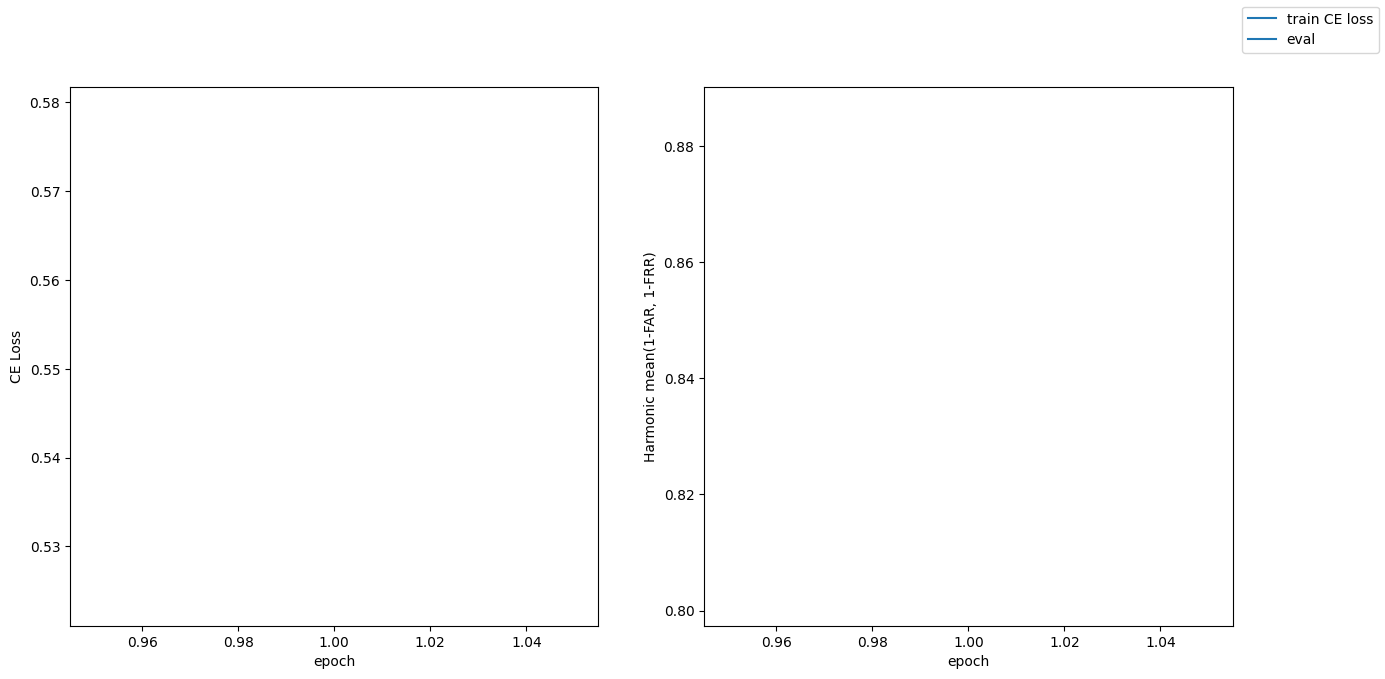

Epoch 1. Train loss 0.55141103337441. Eval score 0.8438054592196991


In [44]:
model = EcapaTDNN(FEATS, 2, 256).to(DEVICE)
opt = optim.Adam(model.parameters())
writer = SummaryWriter(comment="EcapaTDNN")
train(model, opt, writer=writer)

In [45]:
model.eval()
print(calc_eval_score(model, torch_data.Subset(valset, range(1000)), batch_size=128))

  0%|          | 0/8 [00:00<?, ?it/s]

(np.float64(0.84865269672606), np.float64(0.6816143905697157))


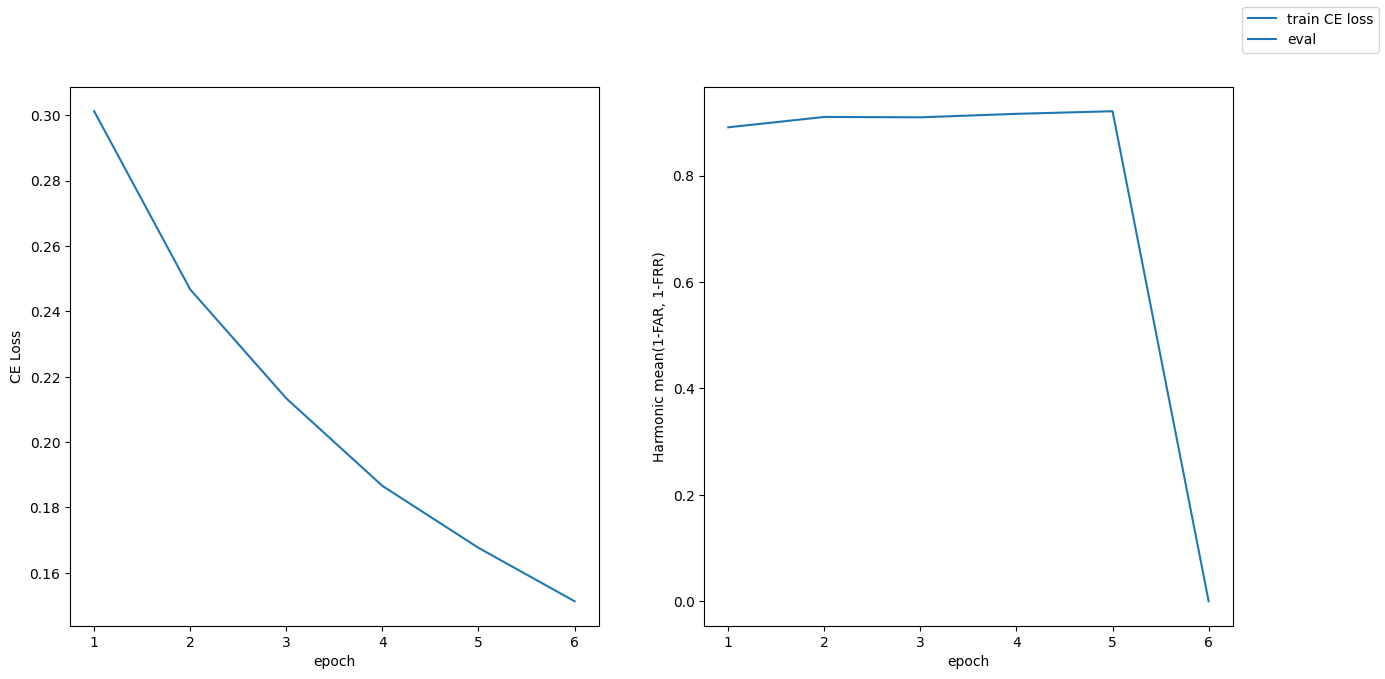

Epoch 6. Train loss 0.1512884323463392. Eval score 0.0


  0%|          | 0/299 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [50]:
train(model, opt, writer=writer, epochs=10)

In [51]:
model.eval()
print(calc_eval_score(model, torch_data.Subset(valset, range(1000)), batch_size=128))

  0%|          | 0/8 [00:00<?, ?it/s]

(np.float64(0.9265399160752215), np.float64(0.245824475533999))


In [53]:
save_test_preds(model, output_file="submission_1.csv")

  0%|          | 0/53 [00:00<?, ?it/s]

best_thr=np.float64(0.3980647196721791)


  0%|          | 0/106 [00:00<?, ?it/s]

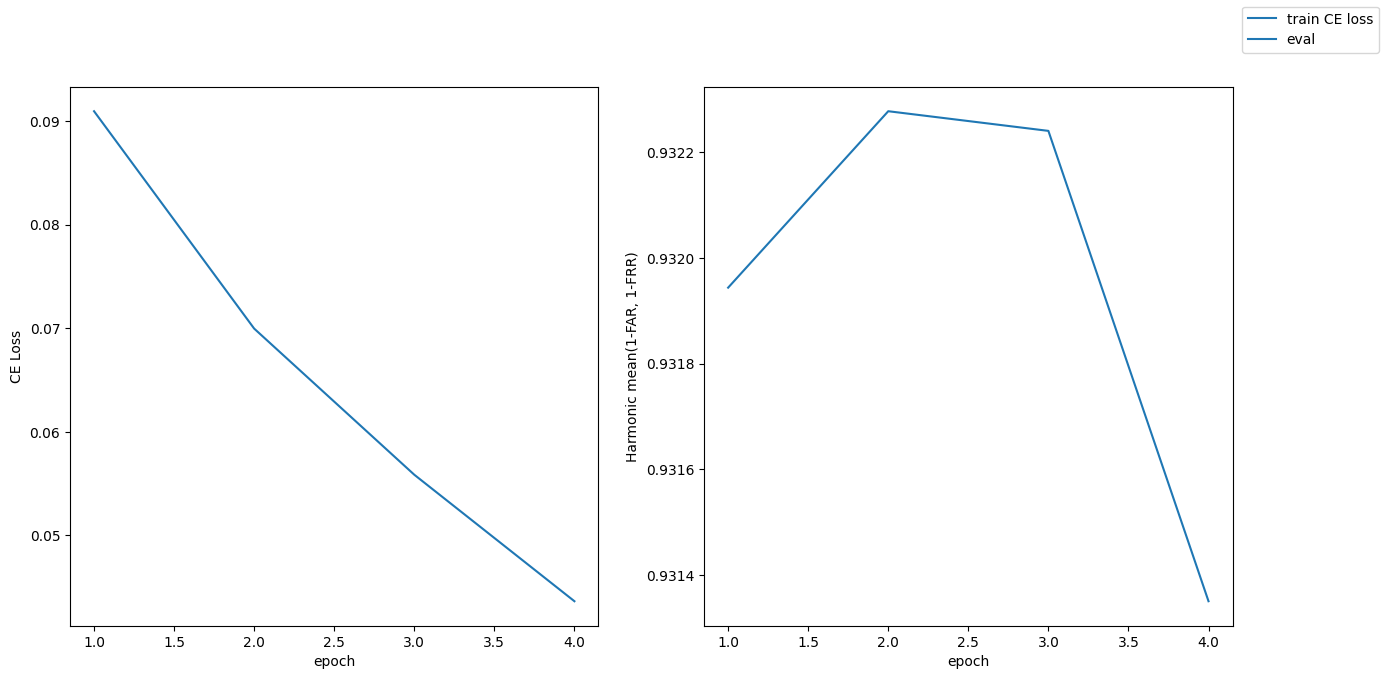

Epoch 4. Train loss 0.04365475492763728. Eval score 0.9313509484401928


  0%|          | 0/598 [00:00<?, ?it/s]

  0%|          | 0/106 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [62]:
opt = optim.AdamW(model.parameters(), lr=1e-4)
train(model, opt, batch_size=128, writer=writer, epochs=5)

In [66]:
model = EcapaTDNN(FEATS, 2, 256).to(DEVICE)
model.load_state_dict(torch.load('best_model_0.9322.pth'))
save_test_preds(model, output_file="submission_2.csv")

  0%|          | 0/53 [00:00<?, ?it/s]

best_thr=np.float64(0.5348720886000436)


  0%|          | 0/106 [00:00<?, ?it/s]